## 2. Scikit-learn

En esta sección se construye un pipeline base en **scikit-learn** utilizando la muestra representativa del dataset y la selección preliminar de variables definida anteriormente.

El objetivo de esta fase es:

- preparar los datos para el modelado,
- aplicar el preprocesamiento adecuado,
- entrenar un modelo base con `MLPClassifier`,
- y obtener una primera evaluación del desempeño antes de realizar ajuste de hiperparámetros.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Antes de comenzar con el modelo, debemos cargar los datos limpios del EDA.

In [2]:
df=pd.read_csv(r"C:\DL\miniproyecto_1\data\data_limpia.csv")

### Definición de variables de entrada y variable objetivo

Se construyen la matriz de características `X` y el vector objetivo `y` a partir de la selección base definida para scikit-learn.

In [3]:
SAMPLE_TRAIN = 1000000
RANDOM_STATE = 42

if SAMPLE_TRAIN > 0:
    df_train_sample = df.sample(
        n=SAMPLE_TRAIN,
        random_state=RANDOM_STATE
    )
else:
    df_train_sample = df

In [4]:
X=df_train_sample.drop(columns=['click'], axis=1).copy()
y=df_train_sample['click']
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Dimensión de X: (1000000, 15)
Dimensión de y: (1000000,)


### Identificación de variables categóricas y numéricas

Dado que el pipeline requiere transformaciones distintas según el tipo de variable, se separan las variables categóricas y numéricas.

In [5]:
numeric_features = [
    'banner_pos',
    'day',
    'hour_of_day'
]

# =========================
# Características categóricas
# =========================
categorical_features = [
    'C1',
    'site_domain',
    'site_category',
    'app_domain',
    'app_category',
    'device_type',
    'device_conn_type',
    'C16',
    'C18',
    'C19',
    'C20'
]

print("Variables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Variables categóricas:
['C1', 'site_domain', 'site_category', 'app_domain', 'app_category', 'device_type', 'device_conn_type', 'C16', 'C18', 'C19', 'C20']

Variables numéricas:
['banner_pos', 'day', 'hour_of_day']


### División en entrenamiento y prueba

Se divide el dataset en conjuntos de entrenamiento y prueba, utilizando una partición 80/20 y preservando la proporción de la variable objetivo mediante estratificación.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800000, 15)
X_test : (200000, 15)
y_train: (800000,)
y_test : (200000,)


In [7]:
print("Distribución de clases en y_train:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nDistribución de clases en y_test:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

Distribución de clases en y_train:
click
0    0.8303
1    0.1697
Name: proportion, dtype: float64

Distribución de clases en y_test:
click
0    0.8303
1    0.1697
Name: proportion, dtype: float64


### Preprocesamiento de variables

Se define un preprocesamiento diferenciado:

- Para variables numéricas:
  - escalado con `StandardScaler`.
- Para variables categóricas:
  - codificación con `OneHotEncoder`.

Este preprocesamiento se integra dentro de un `ColumnTransformer` para garantizar consistencia entre entrenamiento y prueba.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder
# ─── Columnas separadas por cardinalidad ────────────────────────────────────
cat_low  = [c for c in categorical_features if X[c].nunique() <= 10]
cat_high = [c for c in categorical_features if X[c].nunique() >  10]

# ─── Transformadores ────────────────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_low_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

categorical_high_transformer = Pipeline(steps=[
    ('encoder', TargetEncoder(smooth=10))   # reemplaza por CTR promedio
])

# ─── ColumnTransformer unificado ────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num',      numeric_transformer,            numeric_features),
    ('cat_low',  categorical_low_transformer,    cat_low),
    ('cat_high', categorical_high_transformer,   cat_high)
])

### Modelo base con MLPClassifier

Se construye una primera red neuronal multicapa con una configuración sencilla, que servirá como línea base antes del ajuste de hiperparámetros.

In [22]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(50,),
    alpha=0.0001,
    max_iter=50,
    random_state=42
)

In [23]:
pipeline_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", mlp_baseline)
])

pipeline_baseline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['banner_pos', 'day',
                                                   'hour_of_day']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['C1', 'device_type',
                                                   'device_conn_type', 'C16',
                                                   'C18']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('encoder',
                                                                   TargetEncoder(smooth=10))]),
                                                  ['site_domain',
                                                   'site_category',
                                                   'app_domain', 'app_category',
                                                   'C19', 'C20'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50,), max_iter=50,
                               random_state=42))])

### Entrenamiento del modelo base

Se mide el tiempo de entrenamiento del pipeline completo, incluyendo preprocesamiento y ajuste del modelo.

In [27]:
start_train = time.time()

pipeline_baseline.fit(X_train, y_train)

end_train = time.time()
train_time = end_train - start_train

print(f"Tiempo de entrenamiento: {train_time:.2f} segundos")

Tiempo de entrenamiento: 277.15 segundos


### Predicción sobre el conjunto de prueba

Se generan predicciones de clase y probabilidades estimadas para evaluar el modelo con distintas métricas.

In [28]:
start_pred = time.time()

y_pred = pipeline_baseline.predict(X_test)
y_proba = pipeline_baseline.predict_proba(X_test)[:, 1]

end_pred = time.time()
pred_time = end_pred - start_pred

print(f"Tiempo de predicción: {pred_time:.2f} segundos")

Tiempo de predicción: 1.20 segundos


### Evaluación inicial del modelo

Se calculan métricas de clasificación para evaluar el desempeño del modelo base sobre el conjunto de prueba.

In [29]:
baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}

baseline_metrics_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["Metric", "Value"]
)

baseline_metrics_df

,Metric,Value
0,Accuracy,0.831465
1,Precision,0.518593
2,Recall,0.098595
3,F1-score,0.165689
4,ROC AUC,0.720569


In [30]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8419    0.9813    0.9063    166053
           1     0.5186    0.0986    0.1657     33947

    accuracy                         0.8315    200000
   macro avg     0.6802    0.5399    0.5360    200000
weighted avg     0.7870    0.8315    0.7806    200000



Como podemos ver, el desbalance de los datos se hace muy notorio en las métricas:

- **Accuracy**: Este nos indica un "buen" desempeño de la red neuronal con un valor de `0.83` aproximadamente, sin embargo quedándonos solo con esta métrica no vemos el panoráma completo.

- **Recall de la clase positiva**: Con un valor de `0.0986`, nos indica una pobre detección de los **positivos reales** del conjunto de prueba.

- **Precision de la clase positiva**: El resultado de `0.52` aproximadamente en esta métrica nos indica que de los que clasifica como positivos, un poco más de la mitad de estas clasificaciones es correcta, por lo que en este sentido supera por poco al azar.

- **ROC AUC**: Una métrica que nos indica como podemos seguir nuestro análisis es el valor auc de la curva ROC, con un valor de `0.72 aproximadamente`, es decir, la probabilidad de que un positivo real tenga mayor probabilidad de pertenecer a la clase positiva que un negativo real es de 0.72, lo cual es importante ya que al ser un valor más elevado que los otros podemos pensar que el problema es el **umbral de decisión**. Esta información es crucial para la búsqueda de mejores parámetros que realizaremos más adelante.



### Matriz de confusión

La matriz de confusión permite observar con mayor detalle los aciertos y errores del modelo, especialmente en un problema con clases desbalanceadas.

In [31]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

cm_df

,Pred 0,Pred 1
Real 0,162946,3107
Real 1,30600,3347


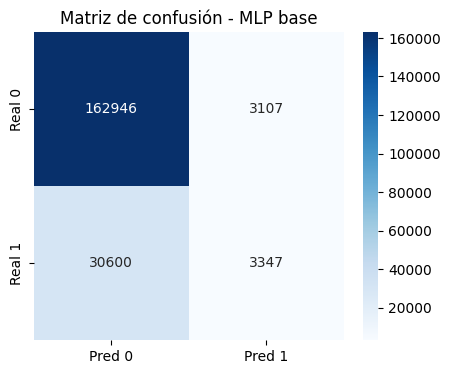

In [32]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - MLP base")
plt.show()

### Curva ROC

Se visualiza la curva ROC para analizar la capacidad discriminativa del modelo base.

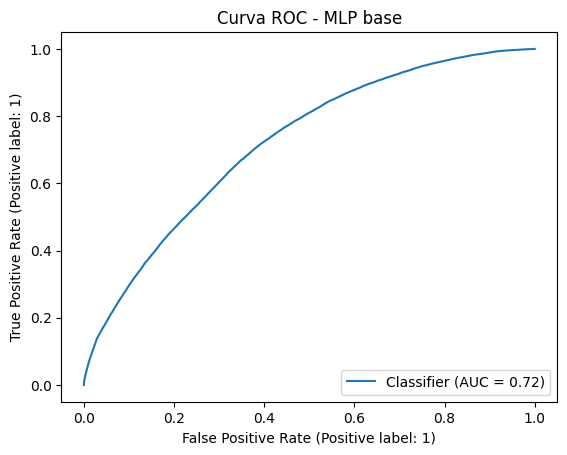

In [33]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC - MLP base")
plt.show()

In [34]:
times_df = pd.DataFrame({
    "Etapa": ["Entrenamiento", "Predicción"],
    "Tiempo (segundos)": [train_time, pred_time]
})

times_df

,Etapa,Tiempo (segundos)
0,Entrenamiento,277.147948
1,Predicción,1.203010


### Interpretación preliminar

El modelo base con `MLPClassifier` permite establecer una línea inicial de desempeño utilizando únicamente la selección base de variables y un pipeline estándar de preprocesamiento.

A partir de estas métricas preliminares, el siguiente paso será realizar ajuste de hiperparámetros para explorar si configuraciones más adecuadas de la red neuronal permiten mejorar el desempeño predictivo, especialmente en métricas sensibles al desbalance de clases como **recall**, **F1-score** y **ROC AUC**.

## Ajuste de hiperparámetros con GridSearchCV

Una vez construido el modelo base, se realiza una búsqueda de hiperparámetros para identificar configuraciones de la red neuronal multicapa que mejoren el desempeño predictivo.

Debido al tamaño del conjunto de datos, el ajuste se realizará sobre una submuestra del conjunto de entrenamiento, manteniendo la evaluación final sobre el conjunto de prueba completo.

In [35]:
from sklearn.model_selection import GridSearchCV

### Submuestra del conjunto de entrenamiento para tuning

Para reducir el costo computacional del ajuste de hiperparámetros, se toma una submuestra estratificada del conjunto de entrenamiento.

In [ ]:

X_train_tune = X_train
y_train_tune = y_train

print("Dimensión de X_train_tune:", X_train_tune.shape)
print("Dimensión de y_train_tune:", y_train_tune.shape)

print("\nDistribución de clases en y_train_tune:")
print(y_train_tune.value_counts(normalize=True).sort_index().round(4))

Dimensión de X_train_tune: (800000, 15)
Dimensión de y_train_tune: (800000,)

Distribución de clases en y_train_tune:
click
0    0.8303
1    0.1697
Name: proportion, dtype: float64


In [39]:
mlp_for_grid = MLPClassifier(
    random_state=42,
    early_stopping=True,
    n_iter_no_change=5
)

pipeline_grid = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", mlp_for_grid)
])

### Definición del espacio de búsqueda

Se prueban distintas combinaciones de arquitectura de la red, regularización y número máximo de iteraciones.

In [40]:
param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__max_iter": [50, 100]
}

param_grid

{'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
 'model__alpha': [0.0001, 0.001, 0.01],
 'model__max_iter': [50, 100]}

### Configuración de GridSearchCV

La búsqueda de hiperparámetros se realiza utilizando validación cruzada y como criterio principal de selección la métrica **F1**, dado que el problema presenta desbalance de clases.

In [42]:
grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

### Entrenamiento del proceso de búsqueda

Se mide el tiempo total requerido para el ajuste de hiperparámetros.

In [43]:
start_grid = time.time()

grid_search.fit(X_train_tune, y_train_tune)

end_grid = time.time()
grid_time = end_grid - start_grid

print(f"Tiempo total de GridSearchCV: {grid_time:.2f} segundos")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tiempo total de GridSearchCV: 1060.41 segundos


In [58]:
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor score promedio en validación cruzada (roc auc):")
print(grid_search.best_score_)

Mejores hiperparámetros encontrados:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__max_iter': 50}

Mejor score promedio en validación cruzada (roc auc):
0.7184137881808287


In [45]:
grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results = grid_results.sort_values("rank_test_score").reset_index(drop=True)

grid_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10)

,params,mean_test_score,std_test_score,rank_test_score
0,"{'model__alpha': 0.0001, 'model__hidden_layer_...",0.718414,0.002702,1
1,"{'model__alpha': 0.0001, 'model__hidden_layer_...",0.716050,0.005508,2
2,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.715530,0.001129,3
3,"{'model__alpha': 0.0001, 'model__hidden_layer_...",0.715247,0.001831,4
4,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.713966,0.002581,5
5,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.713957,0.004832,6
6,"{'model__alpha': 0.0001, 'model__hidden_layer_...",0.713710,0.003954,7
7,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.713256,0.003553,8
8,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.713223,0.003607,9
9,"{'model__alpha': 0.001, 'model__hidden_layer_s...",0.712592,0.002753,10


### Selección del mejor modelo

Se toma el mejor pipeline encontrado por GridSearchCV y se evalúa posteriormente sobre el conjunto de prueba.

In [46]:
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['banner_pos', 'day',
                                                   'hour_of_day']),
                                                 ('cat_low',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['C1', 'device_type',
                                                   'device_conn_type', 'C16',
                                                   'C18']),
                                                 ('cat_high',
                                                  Pipeline(steps=[('encoder',
                                                                   TargetEncoder(smooth=10))]),
                                                  ['site_domain',
                                                   'site_category',
                                                   'app_domain', 'app_category',
                                                   'C19', 'C20'])])),
                ('model',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=(100, 50), max_iter=50,
                               n_iter_no_change=5, random_state=42))])

In [47]:
start_best_pred = time.time()

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

end_best_pred = time.time()
best_pred_time = end_best_pred - start_best_pred

print(f"Tiempo de predicción del mejor modelo: {best_pred_time:.2f} segundos")

Tiempo de predicción del mejor modelo: 0.86 segundos


### Evaluación del mejor modelo en el conjunto de prueba

Se calculan las principales métricas de clasificación para comparar el modelo ajustado con el baseline.

In [48]:
best_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_best, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba_best)
}

best_metrics_df = pd.DataFrame(
    best_metrics.items(),
    columns=["Metric", "Value"]
)

best_metrics_df

,Metric,Value
0,Accuracy,0.832095
1,Precision,0.612685
2,Recall,0.029310
3,F1-score,0.055944
4,ROC AUC,0.712321


In [49]:
print(classification_report(y_test, y_pred_best, digits=4))

              precision    recall  f1-score   support

           0     0.8339    0.9962    0.9079    166053
           1     0.6127    0.0293    0.0559     33947

    accuracy                         0.8321    200000
   macro avg     0.7233    0.5128    0.4819    200000
weighted avg     0.7963    0.8321    0.7633    200000



In [50]:
cm_best = confusion_matrix(y_test, y_pred_best)

cm_best_df = pd.DataFrame(
    cm_best,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

cm_best_df

,Pred 0,Pred 1
Real 0,165424,629
Real 1,32952,995


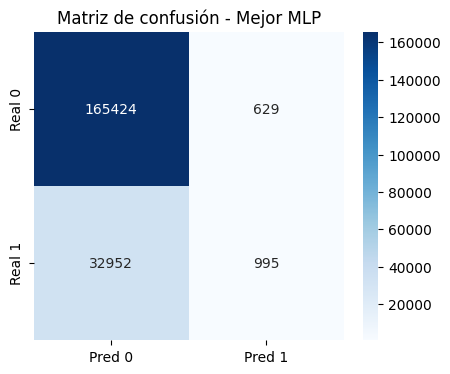

In [51]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Mejor MLP")
plt.show()

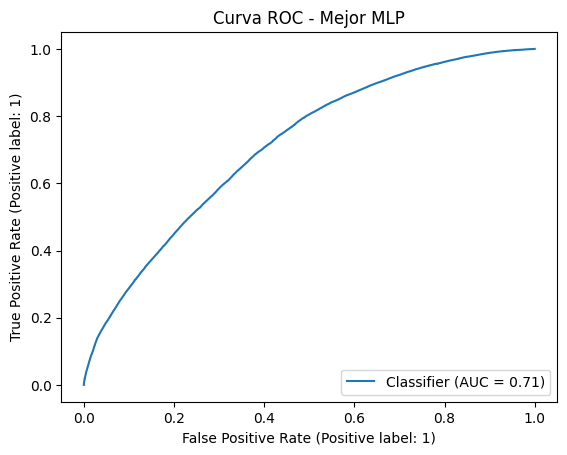

In [52]:
RocCurveDisplay.from_predictions(y_test, y_proba_best)
plt.title("Curva ROC - Mejor MLP")
plt.show()

### Comparación entre el modelo base y el modelo ajustado

Se comparan las métricas principales del baseline y del mejor modelo encontrado mediante GridSearchCV.

In [53]:
comparison_df = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline": list(baseline_metrics.values()),
    "Tuned MLP": [best_metrics[m] for m in baseline_metrics.keys()]
})

comparison_df

,Metric,Baseline,Tuned MLP
0,Accuracy,0.831465,0.832095
1,Precision,0.518593,0.612685
2,Recall,0.098595,0.029310
3,F1-score,0.165689,0.055944
4,ROC AUC,0.720569,0.712321


In [54]:
timing_comparison_df = pd.DataFrame({
    "Etapa": ["Entrenamiento baseline", "Predicción baseline", "GridSearchCV total", "Predicción mejor modelo"],
    "Tiempo (segundos)": [train_time, pred_time, grid_time, best_pred_time]
})

timing_comparison_df

,Etapa,Tiempo (segundos)
0,Entrenamiento baseline,277.147948
1,Predicción baseline,1.203010
2,GridSearchCV total,1060.412184
3,Predicción mejor modelo,0.859700


### Interpretación del ajuste de hiperparámetros

Por sí solo el ajuste de hiperparámetros no ofrece mejoras significativas en el desempeño comparado con el modelo base, pero se tuvo una mejora en la métrica precision de `0.52` a `0.61`. Veremos ahora el ajuste del umbral de clasificación para mejorar estos resultados.

## Ajuste de umbral de clasificación

Dado que el problema presenta desbalance de clases, el umbral estándar de 0.5 puede no ser el más adecuado para detectar correctamente la clase positiva (`click = 1`).

En esta sección se evalúan distintos umbrales de decisión a partir de las probabilidades predichas por el mejor modelo ajustado, con el fin de analizar su efecto sobre métricas como **precision**, **recall** y **F1-score**, y seleccionar un punto de corte más conveniente.

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

### Evaluación de múltiples umbrales

Se prueban distintos valores de umbral para convertir probabilidades en clases predichas y se calculan métricas de desempeño para cada uno.

In [56]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    
    threshold_results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.05,0.304355,0.192691,0.971397,0.321590
1,0.10,0.466300,0.225572,0.881286,0.359204
2,0.15,0.584310,0.255849,0.759242,0.382727
3,0.20,0.677705,0.284056,0.591157,0.383728
4,0.25,0.775360,0.343500,0.354995,0.349153
5,0.30,0.811285,0.401372,0.227531,0.290425
6,0.35,0.828250,0.480286,0.144608,0.222288
7,0.40,0.830265,0.500000,0.120305,0.193945
8,0.45,0.832390,0.571718,0.049901,0.091791
9,0.50,0.832095,0.612685,0.029310,0.055944


In [57]:
best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_threshold_row

threshold    0.200000
accuracy     0.677705
precision    0.284056
recall       0.591157
f1           0.383728
Name: 3, dtype: float64

In [59]:
best_threshold = best_threshold_row["threshold"]
print(f"Mejor umbral según F1: {best_threshold:.2f}")

Mejor umbral según F1: 0.20


### Comportamiento de las métricas según el umbral

Se visualiza cómo cambian precision, recall y F1-score al modificar el umbral de clasificación.

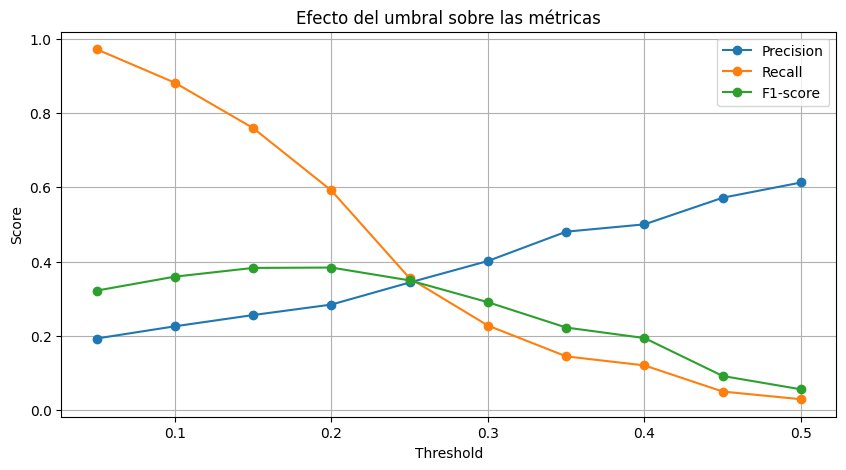

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1-score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Efecto del umbral sobre las métricas")
plt.legend()
plt.grid(True)
plt.show()

### Predicciones usando el umbral seleccionado

Una vez identificado el mejor umbral según la métrica F1, se recalculan las predicciones finales y se evalúa nuevamente el modelo.

In [61]:
y_pred_threshold = (y_proba_best >= best_threshold).astype(int)

In [62]:
threshold_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_threshold),
    "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
    "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_threshold, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba_best)
}

threshold_metrics_df = pd.DataFrame(
    threshold_metrics.items(),
    columns=["Metric", "Value"]
)

threshold_metrics_df

,Metric,Value
0,Accuracy,0.677705
1,Precision,0.284056
2,Recall,0.591157
3,F1-score,0.383728
4,ROC AUC,0.712321


In [63]:
print(classification_report(y_test, y_pred_threshold, digits=4))

              precision    recall  f1-score   support

           0     0.8927    0.6954    0.7818    166053
           1     0.2841    0.5912    0.3837     33947

    accuracy                         0.6777    200000
   macro avg     0.5884    0.6433    0.5828    200000
weighted avg     0.7894    0.6777    0.7142    200000



In [64]:
cm_threshold = confusion_matrix(y_test, y_pred_threshold)

cm_threshold_df = pd.DataFrame(
    cm_threshold,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

cm_threshold_df

,Pred 0,Pred 1
Real 0,115473,50580
Real 1,13879,20068


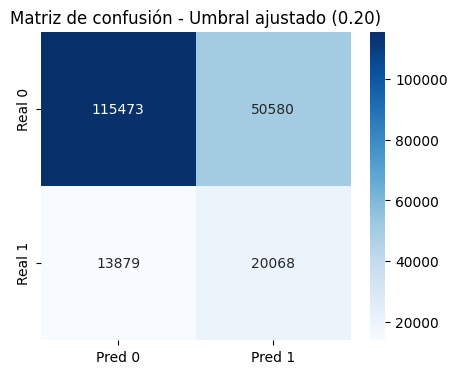

In [65]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_threshold_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - Umbral ajustado ({best_threshold:.2f})")
plt.show()

### Comparación entre baseline, modelo ajustado y modelo con umbral optimizado

Se comparan las métricas obtenidas en tres escenarios:

- modelo base,
- mejor modelo tras GridSearchCV,
- mejor modelo con umbral optimizado.

In [66]:
comparison_all_df = pd.DataFrame({
    "Metric": list(baseline_metrics.keys()),
    "Baseline": [baseline_metrics[m] for m in baseline_metrics.keys()],
    "Tuned MLP": [best_metrics[m] for m in baseline_metrics.keys()],
    "Tuned + Threshold": [threshold_metrics[m] for m in baseline_metrics.keys()]
})

comparison_all_df

,Metric,Baseline,Tuned MLP,Tuned + Threshold
0,Accuracy,0.831465,0.832095,0.677705
1,Precision,0.518593,0.612685,0.284056
2,Recall,0.098595,0.029310,0.591157
3,F1-score,0.165689,0.055944,0.383728
4,ROC AUC,0.720569,0.712321,0.712321


### Interpretación del ajuste de umbral

El ajuste de umbral permite adaptar la decisión final del clasificador al contexto del problema. En datasets desbalanceados, mantener el umbral estándar de 0.5 puede llevar a una detección insuficiente de la clase minoritaria.

Al modificar el umbral, se observa un intercambio entre **precision** y **recall**. En este caso, la selección del umbral basada en **F1-score** busca un equilibrio entre ambas métricas, mejorando la capacidad del modelo para identificar clics sin depender únicamente de la exactitud global.

El ajuste de umbral produjo una disminución en accuracy y precision, pero permitió incrementar el recall y mejorar el F1-score. Este comportamiento es esperable en problemas de clasificación desbalanceada, donde reducir el umbral hace al modelo más sensible a la clase positiva, a costa de incrementar los falsos positivos.

En este contexto, la mejora en F1-score resulta relevante, ya que indica un mejor equilibrio entre precision y recall respecto al modelo con umbral estándar.

El modelo baseline y el modelo ajustado con GridSearchCV mostraron valores de accuracy relativamente altos, pero un desempeño muy limitado en la detección de la clase positiva, reflejado en recalls y F1-scores bajos. Esto indica que, con el umbral estándar de 0.5, el clasificador tendía a favorecer la clase mayoritaria.

En contraste, el ajuste de umbral produjo una reducción en accuracy y precision, pero permitió incrementar de manera sustancial el recall y el F1-score. En particular, el F1-score aumentó de 0.055944 a 0.383728 y el recall de 0.029310 a 0.591157, lo que evidencia una mejora significativa en la capacidad del modelo para identificar clics.

Por esta razón, el modelo ajustado con umbral optimizado se considera el más adecuado dentro del entorno scikit-learn, ya que ofrece un mejor equilibrio entre precision y recall en un contexto de clases desbalanceadas.

## Interpretabilidad local con LIME

Una vez seleccionado el modelo final en scikit-learn y ajustado el umbral de decisión para mejorar el equilibrio entre `precision` y `recall`, se incorpora una técnica de interpretabilidad local llamada **LIME** (*Local Interpretable Model-agnostic Explanations*).

LIME permite explicar predicciones individuales del modelo, identificando qué variables fueron más influyentes en la clasificación de cada observación. Esto resulta especialmente útil en modelos como `MLPClassifier`, cuya estructura interna no es fácilmente interpretable de forma directa.

En esta sección se construirá un explicador local para:

- analizar predicciones individuales,
- identificar variables que empujan la predicción hacia la clase positiva o negativa,
- y examinar casos correctamente clasificados y casos de error, como falsos positivos o falsos negativos.

In [67]:
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Extracción del preprocesador y del modelo final

Dado que el mejor modelo encontrado mediante `GridSearchCV` corresponde a un pipeline completo, se extraen por separado:

- el bloque de preprocesamiento,
- y el clasificador final (`MLPClassifier`).

Esto permite trabajar con las variables transformadas que realmente recibe la red neuronal.

In [68]:
lime_preprocessor = best_model.named_steps["preprocessor"]
lime_model = best_model.named_steps["model"]

print("Preprocesador extraído correctamente.")
print("Modelo final extraído correctamente:")
print(lime_model)

Preprocesador extraído correctamente.
Modelo final extraído correctamente:
MLPClassifier(early_stopping=True, hidden_layer_sizes=(100, 50), max_iter=50,
              n_iter_no_change=5, random_state=42)


### Transformación de los conjuntos de entrenamiento y prueba

LIME necesita trabajar sobre la representación numérica final que utiliza el modelo después del preprocesamiento. Por ello, se transforman los conjuntos de entrenamiento y prueba con el mismo `preprocessor` aprendido dentro del pipeline.

In [69]:
X_train_lime = lime_preprocessor.transform(X_train)
X_test_lime = lime_preprocessor.transform(X_test)

# Convertir a dense si el resultado es sparse
if hasattr(X_train_lime, "toarray"):
    X_train_lime = X_train_lime.toarray()

if hasattr(X_test_lime, "toarray"):
    X_test_lime = X_test_lime.toarray()

print("Dimensión X_train transformado:", X_train_lime.shape)
print("Dimensión X_test transformado:", X_test_lime.shape)

Dimensión X_train transformado: (800000, 38)
Dimensión X_test transformado: (200000, 38)


### Nombres de las variables transformadas

Como el pipeline incluye imputación, escalado y codificación one-hot, el número final de variables que ve el modelo es mayor al número de variables originales.

Por esta razón, se recuperan los nombres finales de las características transformadas para que las explicaciones de LIME sean legibles.

In [70]:
lime_feature_names = lime_preprocessor.get_feature_names_out()

print("Número de variables transformadas:", len(lime_feature_names))
print("Primeras 20 variables:")
print(lime_feature_names[:20])

Número de variables transformadas: 38
Primeras 20 variables:
['num__banner_pos' 'num__day' 'num__hour_of_day' 'cat_low__C1_1001'
 'cat_low__C1_1002' 'cat_low__C1_1005' 'cat_low__C1_1007'
 'cat_low__C1_1008' 'cat_low__C1_1010' 'cat_low__C1_1012'
 'cat_low__device_type_0' 'cat_low__device_type_1'
 'cat_low__device_type_2' 'cat_low__device_type_4'
 'cat_low__device_type_5' 'cat_low__device_conn_type_0'
 'cat_low__device_conn_type_2' 'cat_low__device_conn_type_3'
 'cat_low__device_conn_type_5' 'cat_low__C16_20']


### Construcción del explicador LIME

Se crea un `LimeTabularExplainer` usando el conjunto de entrenamiento transformado. Este explicador generará interpretaciones locales sobre observaciones individuales del conjunto de prueba.

In [71]:
class_names = ["No Click", "Click"]

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=lime_feature_names,
    class_names=class_names,
    mode="classification"
)

print("Explainer de LIME creado correctamente.")

Explainer de LIME creado correctamente.


### Función auxiliar para explicar observaciones individuales

Se define una función que permite:

- seleccionar una observación del conjunto de prueba,
- mostrar su probabilidad estimada,
- aplicar el umbral optimizado,
- comparar la predicción con la clase real,
- y visualizar las variables más influyentes según LIME.

In [72]:
def explain_lime_instance(idx, num_features=10, threshold=best_threshold):
    exp = explainer.explain_instance(
        data_row=X_test_lime[idx],
        predict_fn=lime_model.predict_proba,
        num_features=num_features
    )
    
    proba = lime_model.predict_proba(X_test_lime[idx].reshape(1, -1))[0, 1]
    pred_default = lime_model.predict(X_test_lime[idx].reshape(1, -1))[0]
    pred_threshold = int(proba >= threshold)
    true_label = y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx]
    
    print(f"Índice analizado: {idx}")
    print(f"Valor real: {true_label}")
    print(f"Probabilidad estimada de click: {proba:.4f}")
    print(f"Predicción con umbral 0.5: {pred_default}")
    print(f"Predicción con umbral ajustado ({threshold:.2f}): {pred_threshold}")
    print("\nVariables más influyentes según LIME:")
    
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")
    
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()
    
    return exp

### Ejemplo de explicación individual

Como primera prueba, se explica una observación individual del conjunto de prueba para verificar el funcionamiento del método.

Índice analizado: 0
Valor real: 0
Probabilidad estimada de click: 0.0476
Predicción con umbral 0.5: 0
Predicción con umbral ajustado (0.20): 0

Variables más influyentes según LIME:
cat_high__site_domain <= 0.12: -0.1462
cat_low__C16_480 <= 0.00: -0.1264
cat_low__C18_1 <= 0.00: 0.1064
cat_low__C1_1010 <= 0.00: 0.0945
cat_low__C16_36 <= 0.00: 0.0894
cat_low__C16_250 <= 0.00: 0.0866
cat_low__C1_1012 <= 0.00: -0.0816
cat_low__C16_90 <= 0.00: 0.0790
cat_low__C1_1007 <= 0.00: 0.0651
cat_low__device_type_5 <= 0.00: 0.0619


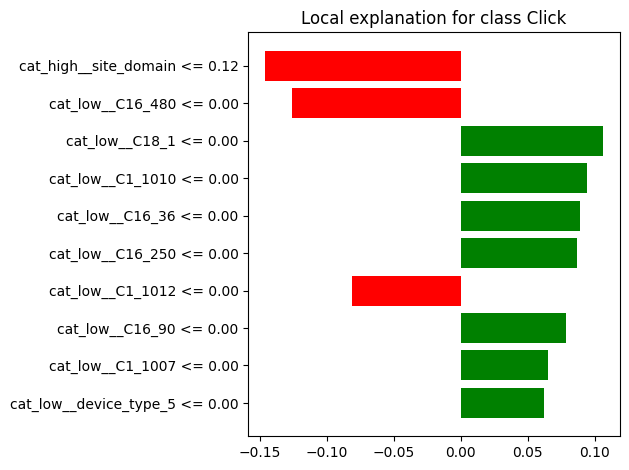

In [73]:
exp_example = explain_lime_instance(idx=0, num_features=10)

### Identificación de casos de interés

Para realizar un análisis más útil, no basta con explicar una observación arbitraria. También conviene identificar ejemplos de:

- verdaderos positivos,
- verdaderos negativos,
- falsos positivos,
- falsos negativos,

tomando como referencia la predicción final basada en el umbral optimizado.

In [74]:
results_lime_df = pd.DataFrame({
    "y_true": y_test.values if hasattr(y_test, "values") else y_test,
    "y_proba": y_proba_best,
    "y_pred_threshold": y_pred_threshold
})

tp_idx = results_lime_df[
    (results_lime_df["y_true"] == 1) & (results_lime_df["y_pred_threshold"] == 1)
].index.tolist()

tn_idx = results_lime_df[
    (results_lime_df["y_true"] == 0) & (results_lime_df["y_pred_threshold"] == 0)
].index.tolist()

fp_idx = results_lime_df[
    (results_lime_df["y_true"] == 0) & (results_lime_df["y_pred_threshold"] == 1)
].index.tolist()

fn_idx = results_lime_df[
    (results_lime_df["y_true"] == 1) & (results_lime_df["y_pred_threshold"] == 0)
].index.tolist()

print("Cantidad de verdaderos positivos:", len(tp_idx))
print("Cantidad de verdaderos negativos:", len(tn_idx))
print("Cantidad de falsos positivos:", len(fp_idx))
print("Cantidad de falsos negativos:", len(fn_idx))

print("\nEjemplo TP:", tp_idx[0] if len(tp_idx) > 0 else "No disponible")
print("Ejemplo TN:", tn_idx[0] if len(tn_idx) > 0 else "No disponible")
print("Ejemplo FP:", fp_idx[0] if len(fp_idx) > 0 else "No disponible")
print("Ejemplo FN:", fn_idx[0] if len(fn_idx) > 0 else "No disponible")

Cantidad de verdaderos positivos: 20068
Cantidad de verdaderos negativos: 115473
Cantidad de falsos positivos: 50580
Cantidad de falsos negativos: 13879

Ejemplo TP: 8
Ejemplo TN: 0
Ejemplo FP: 1
Ejemplo FN: 16


### Explicación de un verdadero positivo

En este caso se analiza una observación que efectivamente corresponde a la clase positiva y que además fue correctamente clasificada por el modelo usando el umbral optimizado.

Índice analizado: 8
Valor real: 1
Probabilidad estimada de click: 0.2497
Predicción con umbral 0.5: 0
Predicción con umbral ajustado (0.20): 1

Variables más influyentes según LIME:
cat_high__site_domain > 0.21: 0.2002
cat_low__C1_1007 <= 0.00: 0.1299
cat_low__C1_1001 <= 0.00: 0.1184
cat_low__C16_90 <= 0.00: 0.1149
cat_low__C18_1 <= 0.00: 0.0992
cat_low__device_type_4 <= 0.00: 0.0981
cat_low__C1_1010 <= 0.00: 0.0946
cat_low__device_type_5 <= 0.00: 0.0856
cat_low__C16_250 <= 0.00: 0.0827
cat_low__C16_36 <= 0.00: 0.0805


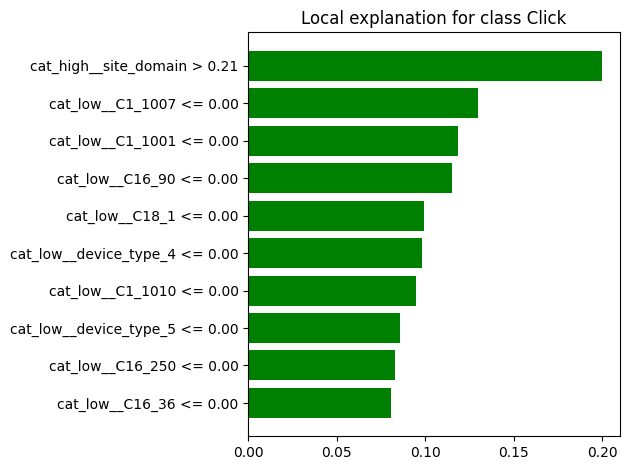

In [76]:
if len(tp_idx) > 0:
    exp_tp = explain_lime_instance(idx=tp_idx[0], num_features=10)
else:
    print("No se encontró ningún verdadero positivo para explicar.")

### Explicación de un falso negativo

El falso negativo es especialmente importante en este problema, ya que corresponde a un caso en el que sí hubo clic, pero el modelo no logró detectarlo.

Analizar este tipo de observaciones permite entender qué factores pudieron empujar erróneamente la predicción hacia la clase negativa.

Índice analizado: 16
Valor real: 1
Probabilidad estimada de click: 0.1555
Predicción con umbral 0.5: 0
Predicción con umbral ajustado (0.20): 0

Variables más influyentes según LIME:
cat_high__site_domain <= 0.12: -0.1528
cat_low__C16_36 <= 0.00: 0.1134
cat_low__C18_1 <= 0.00: 0.1095
cat_low__C1_1010 <= 0.00: 0.1008
cat_low__C1_1001 <= 0.00: 0.0894
cat_low__device_type_4 <= 0.00: 0.0852
cat_low__C16_250 <= 0.00: 0.0767
cat_low__device_conn_type_5 <= 0.00: 0.0739
cat_low__C18_0 <= 0.00: 0.0724
cat_low__device_type_5 <= 0.00: 0.0649


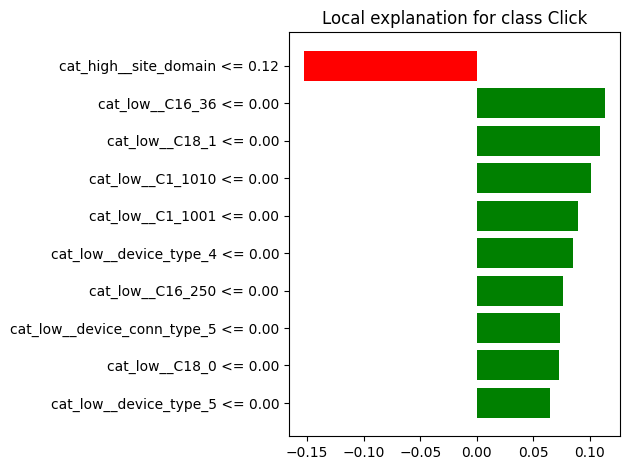

In [77]:
if len(fn_idx) > 0:
    exp_fn = explain_lime_instance(idx=fn_idx[0], num_features=10)
else:
    print("No se encontró ningún falso negativo para explicar.")

### Explicación de un falso positivo

En este caso se analiza una observación que el modelo clasificó como positiva, aunque en realidad pertenecía a la clase negativa.

Esto permite identificar patrones que pueden estar induciendo predicciones de clic incorrectas.

Índice analizado: 1
Valor real: 0
Probabilidad estimada de click: 0.2071
Predicción con umbral 0.5: 0
Predicción con umbral ajustado (0.20): 1

Variables más influyentes según LIME:
cat_low__C16_36 <= 0.00: 0.1136
cat_low__C18_1 <= 0.00: 0.1094
cat_low__C16_320 <= 0.00: 0.1060
cat_low__C1_1010 <= 0.00: 0.1007
cat_low__C1_1007 <= 0.00: -0.0999
cat_low__C16_250 <= 0.00: 0.0936
0.00 < cat_low__C18_0 <= 1.00: -0.0722
cat_low__device_type_4 <= 0.00: 0.0685
cat_low__C18_3 <= 0.00: 0.0573
cat_low__C1_1008 <= 0.00: 0.0437


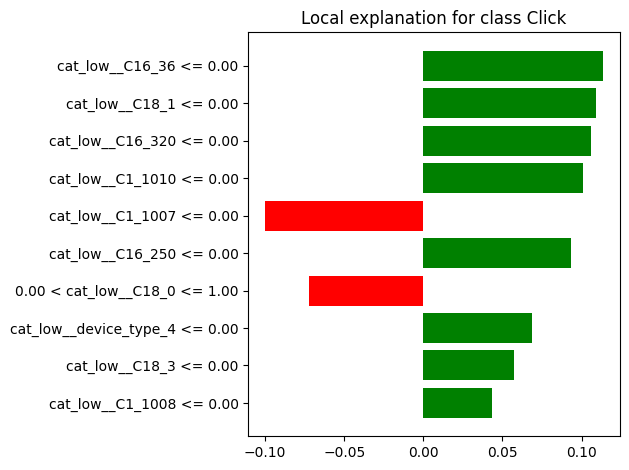

In [78]:
if len(fp_idx) > 0:
    exp_fp = explain_lime_instance(idx=fp_idx[0], num_features=10)
else:
    print("No se encontró ningún falso positivo para explicar.")

### Interpretación general de LIME

Las explicaciones generadas por LIME permiten observar, para cada instancia analizada, qué variables contribuyen a aumentar o disminuir la probabilidad estimada de clic.

En particular:

- las variables con peso positivo empujan la predicción hacia la clase **Click**,
- mientras que las variables con peso negativo empujan la predicción hacia la clase **No Click**.

Dado que el modelo final es una red neuronal multicapa, estas explicaciones locales resultan especialmente valiosas, ya que ofrecen una aproximación interpretable del comportamiento del clasificador en observaciones individuales, aun cuando el modelo global sea complejo.

### Conclusión de la sección

La implementación de LIME permitió complementar la evaluación cuantitativa del modelo con una capa de interpretabilidad local. Esto hizo posible explicar predicciones específicas del `MLPClassifier` y analizar tanto aciertos como errores del modelo final.

Además, al considerar el umbral optimizado en la interpretación de las probabilidades, se logró una lectura más coherente del proceso de decisión del clasificador, especialmente en un contexto de clases desbalanceadas donde la probabilidad estimada y la clase final predicha no siempre coinciden con el umbral estándar de 0.5.

In [79]:
lime_preprocessor = best_model.named_steps["preprocessor"]
lime_model = best_model.named_steps["model"]

### Discusión de los resultados obtenidos con LIME

El análisis local con LIME permitió observar que las predicciones del modelo final están influenciadas de manera recurrente por un conjunto reducido de variables, entre las que destacan  `C16`, `device_type`, algunas categorías de `site_category` y ciertas categorías de `app_category`. Varias categorías del sitio tienden a empujar la predicción hacia la clase positiva, mientras que `C16` aparece repetidamente como una de las señales más influyentes hacia la clase negativa.

Además, las explicaciones mostraron que tanto los verdaderos positivos como los falsos positivos presentan probabilidades estimadas muy cercanas al umbral optimizado de decisión (`0.20`). Esto sugiere que una parte importante del aumento en recall obtenido tras el ajuste de umbral proviene de clasificar como positivos casos fronterizos que, bajo el umbral estándar de `0.5`, habrían sido clasificados como negativos.

Por otra parte, el análisis de falsos negativos evidenció que, incluso cuando existen señales locales que favorecen la clase positiva, algunas variables numéricas con contribución negativa —especialmente `C16`, y en ciertos casos `C18`— pueden dominar la decisión final del modelo. En conjunto, estos hallazgos refuerzan la idea de que el modelo logra recuperar más casos positivos gracias al threshold tuning, pero a costa de una mayor sensibilidad a observaciones ambiguas, lo que explica la reducción observada en la precisión.